In [22]:
#!/usr/bin/env python
from __future__ import annotations

import os
import json
from datetime import datetime, timezone
from typing import Dict, Any, List, Optional, Tuple

import pandas as pd
from sqlalchemy import create_engine, text
from shapely.geometry import shape
from shapely.ops import transform as shp_transform
from pyproj import Transformer
from pystac_client import Client

# ----------------------------------------------------------------------
# Configurações gerais
# ----------------------------------------------------------------------
PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

PG_USER = "postgres"
PG_PASS = "postgres"
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB   = "geologia"

PG_CONN_STR = (
    f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)


# ----------------------------------------------------------------------
# Utilitários gerais
# ----------------------------------------------------------------------
def parse_target_date(date_str: str) -> datetime:
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    return dt.replace(tzinfo=timezone.utc)


def item_datetime(item) -> datetime:
    """
    Extrai datetime (timezone-aware) de um pystac.Item.
    """
    if getattr(item, "datetime", None) is not None:
        dt = item.datetime
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        return dt

    props = getattr(item, "properties", {}) or {}
    dt_str = props.get("datetime") or props.get("start_datetime")
    if dt_str is None:
        raise RuntimeError(f"Item {getattr(item, 'id', '?')} sem campo datetime.")

    if dt_str.endswith("Z"):
        dt_str = dt_str.replace("Z", "+00:00")
    dt = datetime.fromisoformat(dt_str)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt


def get_pc_client() -> Client:
    return Client.open(PC_STAC_URL)


# ----------------------------------------------------------------------
# Acesso ao PostGIS
# ----------------------------------------------------------------------
def get_folha_geom_geojson(
    codigo_folha: str,
    conn_str: str = PG_CONN_STR,
    schema: str = "carto",
    table: str = "folhas_cartograficas",
) -> Dict[str, Any]:
    """
    Retorna a geometria da folha em WGS84 (EPSG:4326) como GeoJSON.
    """
    engine = create_engine(conn_str)
    sql = text(
        f"""
        SELECT ST_AsGeoJSON(ST_Transform(geom, 4326)) AS geom_json
        FROM {schema}.{table}
        WHERE codigo = :codigo
        LIMIT 1;
        """
    )
    with engine.begin() as conn:
        row = conn.execute(sql, {"codigo": codigo_folha}).fetchone()

    if row is None or row.geom_json is None:
        raise RuntimeError(f"Não foi encontrada geometria para a folha '{codigo_folha}'")

    return json.loads(row.geom_json)


def listar_folhas_25k_sb21_za_ii(
    conn_str: str = PG_CONN_STR,
    prefixo: str = "SB21_ZA_II",
) -> List[str]:
    """
    Lista códigos de folhas em carto.folhas_cartograficas cujo código
    começa com prefixo (SB21_ZA_II) e cuja escala é 25k (heurística via CAST).
    """
    engine = create_engine(conn_str)
    sql = text(
        """
        SELECT codigo
        FROM carto.folhas_cartograficas
        WHERE codigo LIKE :pref
          AND (
                CAST(escala AS text) ILIKE '%25k%'
             OR CAST(escala AS text) ILIKE '%25.000%'
             OR CAST(escala AS text) ILIKE '%25000%'
          )
        ORDER BY codigo;
        """
    )
    with engine.begin() as conn:
        rows = conn.execute(sql, {"pref": f"{prefixo}%"}).fetchall()

    return [r.codigo for r in rows]


# ----------------------------------------------------------------------
# Funções geométricas para cobertura
# ----------------------------------------------------------------------
def build_local_equal_area_transformer(geom_geojson: Dict[str, Any]) -> Transformer:
    geom = shape(geom_geojson)
    lon0, lat0 = geom.centroid.x, geom.centroid.y
    laea_proj = (
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+datum=WGS84 +units=m +no_defs"
    )
    return Transformer.from_crs("EPSG:4326", laea_proj, always_xy=True)


def coverage_fraction(
    folha_geom_geojson: Dict[str, Any],
    item_geom_geojson: Dict[str, Any],
    transformer: Transformer,
) -> float:
    folha_geom = shape(folha_geom_geojson)
    item_geom = shape(item_geom_geojson)

    project = transformer.transform
    folha_proj = shp_transform(project, folha_geom)
    item_proj = shp_transform(project, item_geom)

    inter = folha_proj.intersection(item_proj)
    if folha_proj.is_empty or inter.is_empty:
        return 0.0
    return inter.area / folha_proj.area


def get_cloud_cover(item) -> Optional[float]:
    props = getattr(item, "properties", {}) or {}
    for key in ("eo:cloud_cover", "s2:cloud_cover"):
        if key in props and props[key] is not None:
            try:
                return float(props[key])
            except Exception:
                continue
    return None


# ----------------------------------------------------------------------
# Busca ASTER
# ----------------------------------------------------------------------
def search_aster_for_folha(
    codigo_folha: str,
    target_date_str: str,
    collection_id: str = "aster-l1t",
    stac_url: str = PC_STAC_URL,
    search_datetime: str = "2000-01-01/2015-12-31",
    min_coverage: float = 0.90,
    max_cloud: Optional[float] = None,
    max_items: int = 2000,
) -> Tuple[List[Dict[str, Any]], Optional[Dict[str, Any]]]:

    folha_geom_geojson = get_folha_geom_geojson(codigo_folha)
    folha_shape = shape(folha_geom_geojson)
    print(
        f"[ASTER] Folha '{codigo_folha}' carregada. "
        f"Área WGS84 (aprox): {folha_shape.area:.6f} (graus²)"
    )
    transformer = build_local_equal_area_transformer(folha_geom_geojson)

    cat = Client.open(stac_url)
    print(f"[ASTER] Buscando itens em '{collection_id}'...")
    search = cat.search(
        collections=[collection_id],
        intersects=folha_geom_geojson,
        datetime=search_datetime,
        max_items=max_items,
    )
    items = list(search.items())
    print(
        f"[ASTER] Total de itens retornados (antes de filtros locais): {len(items)}"
    )

    if not items:
        return [], None

    target_date = parse_target_date(target_date_str).date()
    candidates: List[Dict[str, Any]] = []

    for item in items:
        dt = item_datetime(item)
        dt_date = dt.date()
        delta_days = abs((dt_date - target_date).days)

        cloud = get_cloud_cover(item)
        if cloud is None:
            continue
        if (max_cloud is not None) and (cloud >= max_cloud):
            continue

        frac = coverage_fraction(
            folha_geom_geojson=folha_geom_geojson,
            item_geom_geojson=item.geometry,
            transformer=transformer,
        )
        if frac < min_coverage:
            continue

        candidates.append(
            {
                "id": item.id,
                "datetime": dt.isoformat(),
                "delta_days": delta_days,
                "coverage_fraction": frac,
                "coverage_percent": frac * 100.0,
                "cloud_cover": cloud,
                "item": item,
            }
        )

    if not candidates:
        print(
            "[ASTER] Nenhum item atendeu a:\n"
            f"  coverage >= {min_coverage*100:.1f}%"
            + (f" e cloud < {max_cloud:.2f}%." if max_cloud is not None else ".")
        )
        return [], None

    candidates.sort(
        key=lambda d: (d["delta_days"], d["cloud_cover"], -d["coverage_fraction"])
    )

    print("\n[ASTER] Itens candidatos (ordenados):")
    for c in candidates:
        print(
            f"  id={c['id']}, "
            f"datetime={c['datetime']}, "
            f"delta_days={c['delta_days']}, "
            f"coverage={c['coverage_percent']:.2f}%, "
            f"cloud={c['cloud_cover']:.2f}%"
        )

    best = candidates[0]
    print(
        "\n[ASTER] Melhor item:\n"
        f"  id={best['id']}\n"
        f"  datetime={best['datetime']}\n"
        f"  delta_days={best['delta_days']}\n"
        f"  coverage={best['coverage_percent']:.2f}%\n"
        f"  cloud={best['cloud_cover']:.2f}%"
    )
    return candidates, best


# ----------------------------------------------------------------------
# Busca Sentinel-2
# ----------------------------------------------------------------------
def search_sentinel2_for_folha(
    codigo_folha: str,
    reference_datetime: datetime,
    collection_id: str = "sentinel-2-l2a",
    stac_url: str = PC_STAC_URL,
    search_datetime: str = "2000-06-23/2100-01-01",
    min_coverage: float = 0.90,
    max_cloud: float = 1.0,
    max_items: int = 2000,
    max_print_candidates: int = 0,  # 0 = não listar; >0 = listar primeiros N
) -> Tuple[List[Dict[str, Any]], Optional[Dict[str, Any]]]:

    folha_geom_geojson = get_folha_geom_geojson(codigo_folha)
    folha_shape = shape(folha_geom_geojson)
    print(
        f"[S2] Folha '{codigo_folha}' carregada. "
        f"Área WGS84 (aprox): {folha_shape.area:.6f} (graus²)"
    )
    transformer = build_local_equal_area_transformer(folha_geom_geojson)
    cat = Client.open(stac_url)

    print(f"[S2] Buscando itens em '{collection_id}'...")
    search = cat.search(
        collections=[collection_id],
        intersects=folha_geom_geojson,
        datetime=search_datetime,
        max_items=max_items,
    )
    items = list(search.items())
    print(
        f"[S2] Total de itens retornados (antes de filtros locais): {len(items)}"
    )

    if not items:
        return [], None

    ref_date = reference_datetime.date()
    candidates: List[Dict[str, Any]] = []

    for item in items:
        dt = item_datetime(item)
        dt_date = dt.date()
        delta_days = abs((dt_date - ref_date).days)

        cloud = get_cloud_cover(item)
        if cloud is None or cloud >= max_cloud:
            continue

        frac = coverage_fraction(
            folha_geom_geojson=folha_geom_geojson,
            item_geom_geojson=item.geometry,
            transformer=transformer,
        )
        if frac < min_coverage:
            continue

        candidates.append(
            {
                "id": item.id,
                "datetime": dt.isoformat(),
                "delta_days": delta_days,
                "coverage_fraction": frac,
                "coverage_percent": frac * 100.0,
                "cloud_cover": cloud,
                "item": item,
            }
        )

    if not candidates:
        print(
            "[S2] Nenhum item atendeu a:\n"
            f"  coverage >= {min_coverage*100:.1f}% e cloud < {max_cloud:.2f}%."
        )
        return [], None

    candidates.sort(
        key=lambda d: (d["delta_days"], d["cloud_cover"], -d["coverage_fraction"])
    )

    if max_print_candidates > 0:
        print(
            f"\n[S2] Itens candidatos (ordenados) "
            f"(primeiros {max_print_candidates} de {len(candidates)}):"
        )
        for c in candidates[:max_print_candidates]:
            print(
                f"  id={c['id']}, "
                f"datetime={c['datetime']}, "
                f"delta_days={c['delta_days']}, "
                f"coverage={c['coverage_percent']:.2f}%, "
                f"cloud={c['cloud_cover']:.2f}%"
            )

    best = candidates[0]
    print(
        "\n[S2] Melhor item:\n"
        f"  id={best['id']}\n"
        f"  datetime={best['datetime']}\n"
        f"  delta_days={best['delta_days']}\n"
        f"  coverage={best['coverage_percent']:.2f}%\n"
        f"  cloud={best['cloud_cover']:.2f}%"
    )
    return candidates, best


# ----------------------------------------------------------------------
# Pipeline de descoberta (sem download/recorte)
# ----------------------------------------------------------------------
def discover_aster_and_s2_for_folha(
    codigo_folha: str,
    aster_target_date_str: str = "2008-07-15",
    aster_search_datetime: str = "2000-01-01/2015-12-31",
    aster_min_coverage: float = 0.90,
    aster_max_cloud: Optional[float] = None,
    s2_search_datetime: str = "2015-06-23/2100-01-01",
    s2_min_coverage: float = 0.90,
    s2_max_cloud: float = 1.0,
    use_aster_date_as_ref_for_s2: bool = True,
) -> Dict[str, Any]:
    """
    Retorna candidatos ASTER e Sentinel-2 com métricas de nuvem/cobertura,
    mas não realiza download de rasters.
    """

    # 1) ASTER
    aster_candidates, aster_best = search_aster_for_folha(
        codigo_folha=codigo_folha,
        target_date_str=aster_target_date_str,
        collection_id="aster-l1t",
        stac_url=PC_STAC_URL,
        search_datetime=aster_search_datetime,
        min_coverage=aster_min_coverage,
        max_cloud=aster_max_cloud,
        max_items=2000,
    )

    # 2) Referência temporal para Sentinel-2
    if use_aster_date_as_ref_for_s2 and aster_best is not None:
        ref_dt_s2 = item_datetime(aster_best["item"])
        print(
            f"\n[PIPELINE] Referência S2 (folha {codigo_folha}) = data da ASTER selecionada: "
            f"{ref_dt_s2.isoformat()}"
        )
    else:
        ref_dt_s2 = parse_target_date(aster_target_date_str)
        print(
            f"\n[PIPELINE] Referência S2 (folha {codigo_folha}) = data alvo aerogeofísica: "
            f"{ref_dt_s2.isoformat()}"
        )

    # 3) Sentinel-2 (sempre roda, independentemente de ASTER ter candidato ou não)
    s2_candidates, s2_best = search_sentinel2_for_folha(
        codigo_folha=codigo_folha,
        reference_datetime=ref_dt_s2,
        collection_id="sentinel-2-l2a",
        stac_url=PC_STAC_URL,
        search_datetime=s2_search_datetime,
        min_coverage=s2_min_coverage,
        max_cloud=s2_max_cloud,
        max_items=2000,
        max_print_candidates=0,  # não listar todos os candidatos S2
    )

    return {
        "aster_candidates": aster_candidates,
        "aster_best": aster_best,
        "s2_candidates": s2_candidates,
        "s2_best": s2_best,
    }


# ----------------------------------------------------------------------
# Main: descoberta contínua para todas as folhas 25k SB21_ZA_II*
# ----------------------------------------------------------------------
def main():
    # 0) Diretório de saída para os CSVs
    out_dir = "./candidatos_orbitais"
    os.makedirs(out_dir, exist_ok=True)

    # 1) Lista de folhas alvo (25k, código começando com SB21_ZA_II2_NW)
    codigos_folhas = listar_folhas_25k_sb21_za_ii(PG_CONN_STR, prefixo="SB21_ZA_II1_NE")
    print(f"Encontradas {len(codigos_folhas)} folhas 25k com 'SB21_ZA_II2_NW' no código:")
    for c in codigos_folhas:
        print(f"  - {c}")

    if not codigos_folhas:
        print("Nenhuma folha encontrada. Encerrando.")
        return

    # 2) Parâmetros globais de busca
    aster_target_date_str = "2008-07-15"
    aster_search_datetime = "2000-01-01/2025-12-31"
    s2_search_datetime = "2000-06-23/2025-01-01"

    # ASTER mais permissivo: menor cobertura mínima, sem filtro de nuvem
    aster_min_coverage = 0.99
    aster_max_cloud = 50.0  # não filtrar por nuvem em ASTER

    # Sentinel-2: mantém filtros restritos
    s2_min_coverage = 0.90
    s2_max_cloud = 1      # % nuvem S2

    all_aster_rows: List[Dict[str, Any]] = []
    all_s2_rows: List[Dict[str, Any]] = []
    all_pairs_rows: List[Dict[str, Any]] = []  # lista com os melhores pares ASTER + S2

    # 3) Loop nas folhas
    for codigo_folha in codigos_folhas:
        print("\n" + "=" * 80)
        print(f"[PIPELINE] Processando folha: {codigo_folha}")
        print("=" * 80)

        res = discover_aster_and_s2_for_folha(
            codigo_folha=codigo_folha,
            aster_target_date_str=aster_target_date_str,
            aster_search_datetime=aster_search_datetime,
            aster_min_coverage=aster_min_coverage,
            aster_max_cloud=aster_max_cloud,
            s2_search_datetime=s2_search_datetime,
            s2_min_coverage=s2_min_coverage,
            s2_max_cloud=s2_max_cloud,
            use_aster_date_as_ref_for_s2=True,
        )

        # ASTER -> linhas para DataFrame global
        for cand in res["aster_candidates"]:
            row = {k: v for k, v in cand.items() if k != "item"}
            row["folha_codigo"] = codigo_folha
            all_aster_rows.append(row)

        # Sentinel-2 -> linhas para DataFrame global
        for cand in res["s2_candidates"]:
            row = {k: v for k, v in cand.items() if k != "item"}
            row["folha_codigo"] = codigo_folha
            all_s2_rows.append(row)

        # -------------------------------
        # Melhor par ASTER + Sentinel-2
        # -------------------------------
        aster_best = res["aster_best"]
        s2_best = res["s2_best"]

        if aster_best is not None and s2_best is not None:
            dt_aster = item_datetime(aster_best["item"])
            dt_s2 = item_datetime(s2_best["item"])
            delta_pair_days = abs((dt_s2.date() - dt_aster.date()).days)

            pair_row = {
                "folha_codigo": codigo_folha,

                "aster_id": aster_best["id"],
                "aster_datetime": dt_aster.isoformat(),
                "aster_cloud": aster_best["cloud_cover"],
                "aster_coverage_fraction": aster_best["coverage_fraction"],
                "aster_coverage_percent": aster_best["coverage_fraction"] * 100.0,

                "s2_id": s2_best["id"],
                "s2_datetime": dt_s2.isoformat(),
                "s2_cloud": s2_best["cloud_cover"],
                "s2_coverage_fraction": s2_best["coverage_fraction"],
                "s2_coverage_percent": s2_best["coverage_fraction"] * 100.0,

                "delta_days_s2_minus_aster": delta_pair_days,
            }
            all_pairs_rows.append(pair_row)

            # (Opcional) imprimir um resumo do par
            print("\n[PAR MELHOR ASTER + S2]")
            print(f"  Folha: {codigo_folha}")
            print(
                f"  ASTER: {pair_row['aster_id']} ({pair_row['aster_datetime']}), "
                f"cov={pair_row['aster_coverage_percent']:.2f}%, "
                f"cloud={pair_row['aster_cloud']:.2f}%"
            )
            print(
                f"  S2   : {pair_row['s2_id']} ({pair_row['s2_datetime']}), "
                f"cov={pair_row['s2_coverage_percent']:.2f}%, "
                f"cloud={pair_row['s2_cloud']:.2f}%"
            )
            print(f"  Δt (S2 - ASTER) = {delta_pair_days} dias")
        else:
            print(
                "\n[PAR MELHOR ASTER + S2] Não foi possível formar par completo "
                f"para a folha {codigo_folha} (falta ASTER ou S2)."
            )

    # 4) Construir DataFrames globais e salvar CSVs
    if all_aster_rows:
        df_aster_all = pd.DataFrame(all_aster_rows)
        out_aster = os.path.join(out_dir, "aster_sb21_za_ii_25k_candidates.csv")
        df_aster_all.to_csv(out_aster, index=False)
        print(f"\n[RESUMO] ASTER: {len(df_aster_all)} linhas salvas em: {out_aster}")
    else:
        print("\n[RESUMO] Nenhum candidato ASTER encontrado para nenhuma folha.")

    if all_s2_rows:
        df_s2_all = pd.DataFrame(all_s2_rows)
        out_s2 = os.path.join(out_dir, "s2_sb21_za_ii_25k_candidates.csv")
        df_s2_all.to_csv(out_s2, index=False)
        print(f"[RESUMO] S2: {len(df_s2_all)} linhas salvas em: {out_s2}")
    else:
        print("[RESUMO] Nenhum candidato Sentinel-2 encontrado para nenhuma folha.")

    # 5) CSV com os melhores pares ASTER + S2
    if all_pairs_rows:
        df_pairs = pd.DataFrame(all_pairs_rows)
        out_pairs = os.path.join(out_dir, "best_pairs_aster_s2_sb21_za_ii_25k.csv")
        df_pairs.to_csv(out_pairs, index=False)
        print(
            f"[RESUMO] Pares ASTER+S2: {len(df_pairs)} linhas salvas em: {out_pairs}"
        )
    else:
        print("[RESUMO] Nenhum par ASTER+S2 completo foi encontrado.")


if __name__ == "__main__":
    main()


Encontradas 1 folhas 25k com 'SB21_ZA_II2_NW' no código:
  - SB21_ZA_II1_NE

[PIPELINE] Processando folha: SB21_ZA_II1_NE
[ASTER] Folha 'SB21_ZA_II1_NE' carregada. Área WGS84 (aprox): 0.015625 (graus²)
[ASTER] Buscando itens em 'aster-l1t'...
[ASTER] Total de itens retornados (antes de filtros locais): 28

[ASTER] Itens candidatos (ordenados):
  id=AST_L1T_00306012006141203_20150514154927, datetime=2006-06-01T14:12:03.804000+00:00, delta_days=775, coverage=100.00%, cloud=42.00%
  id=AST_L1T_00310202005141145_20150511152438, datetime=2005-10-20T14:11:45.205000+00:00, delta_days=999, coverage=100.00%, cloud=11.00%
  id=AST_L1T_00305132005141212_20150509113333, datetime=2005-05-13T14:12:12.600000+00:00, delta_days=1159, coverage=100.00%, cloud=15.00%

[ASTER] Melhor item:
  id=AST_L1T_00306012006141203_20150514154927
  datetime=2006-06-01T14:12:03.804000+00:00
  delta_days=775
  coverage=100.00%
  cloud=42.00%

[PIPELINE] Referência S2 (folha SB21_ZA_II1_NE) = data da ASTER selecionada: 2

In [14]:
import pandas as pd

pairs_csv = "./candidatos_orbitais/best_pairs_aster_s2_sb21_za_ii_25k.csv"
df_pairs = pd.read_csv(pairs_csv)
df_pairs


,folha_codigo,aster_id,aster_datetime,aster_cloud,aster_coverage_fraction,aster_coverage_percent,s2_id,s2_datetime,s2_cloud,s2_coverage_fraction,s2_coverage_percent,delta_days_s2_minus_aster
0,SB21_ZA_II2_NW,AST_L1T_00307292004141220_20150505110335,2004-07-29T14:12:20.641000+00:00,0.0,1.0,100.0,S2A_MSIL2A_20170609T141051_R110_T21MWP_2021020...,2017-06-09T14:10:51.026000+00:00,0.073414,1.0,100.0,4698


In [15]:
df_pairs.s2_id

0    S2A_MSIL2A_20170609T141051_R110_T21MWP_2021020...
Name: s2_id, dtype: object


[ASTER] Item selecionado: AST_L1T_00307292004141220_20150505110335
  cloud_cover (metadado de cena): 0.0 %
  Assets disponíveis: ['TIR', 'xml', 'SWIR', 'VNIR', 'qa-txt', 'tilejson', 'tir-browse', 'vnir-browse', 'rendered_preview']
  Lendo asset 'VNIR' e recortando para a folha...
  Fração de pixels nodata no recorte ASTER: 0.0034


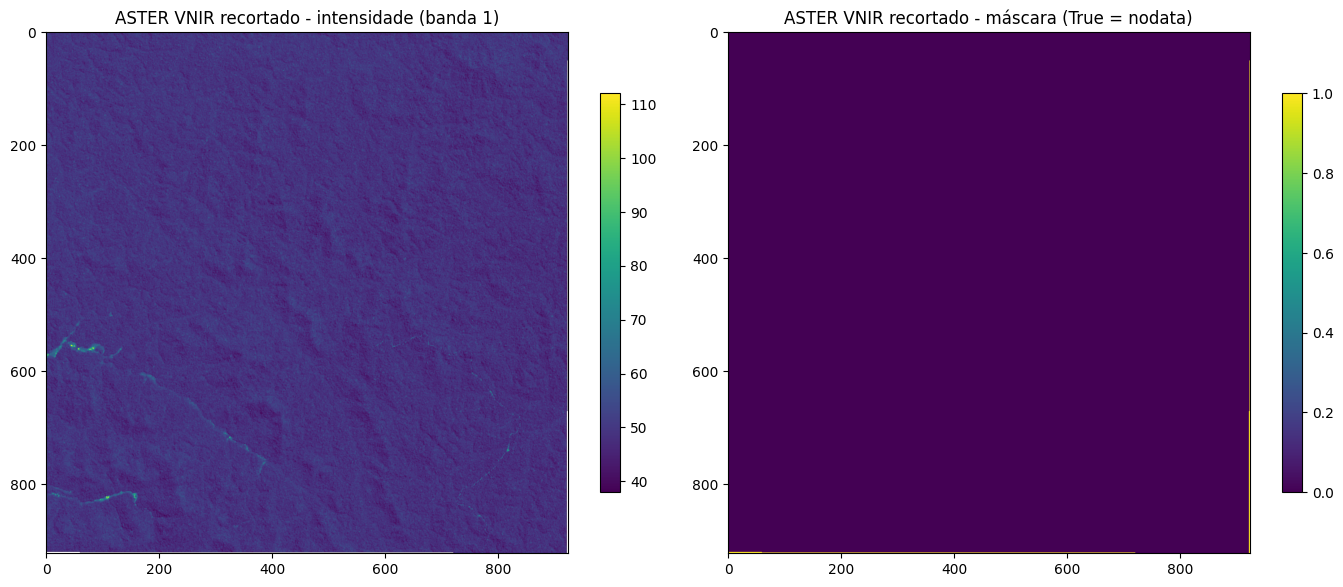


[S2] Item selecionado: S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220
  cloud_cover (metadado de cena): 0.073414 %
  Assets disponíveis: ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'preview', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview']
  Lendo asset 'visual' e recortando para a folha...
  Fração de pixels nodata no recorte S2 (visual): 0.0027


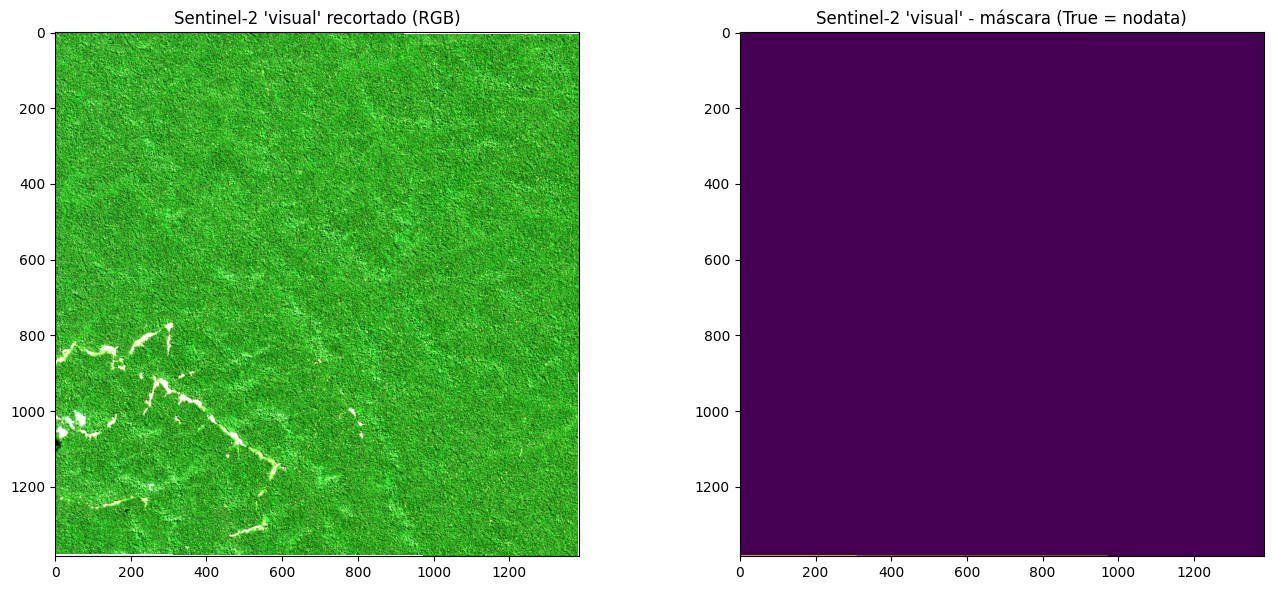

  Lendo asset 'SCL' e recortando para a folha...


/tmp/ipykernel_1368366/2236367902.py:247: RuntimeWarning: invalid value encountered in cast
  scl = scl.astype("int16")



[S2] Fração de nodata no SCL (código 0): 0.0034
[S2] Fração de 'nuvem/sombra/neve' (SCL in {3,8,9,10,11}): 0.0004


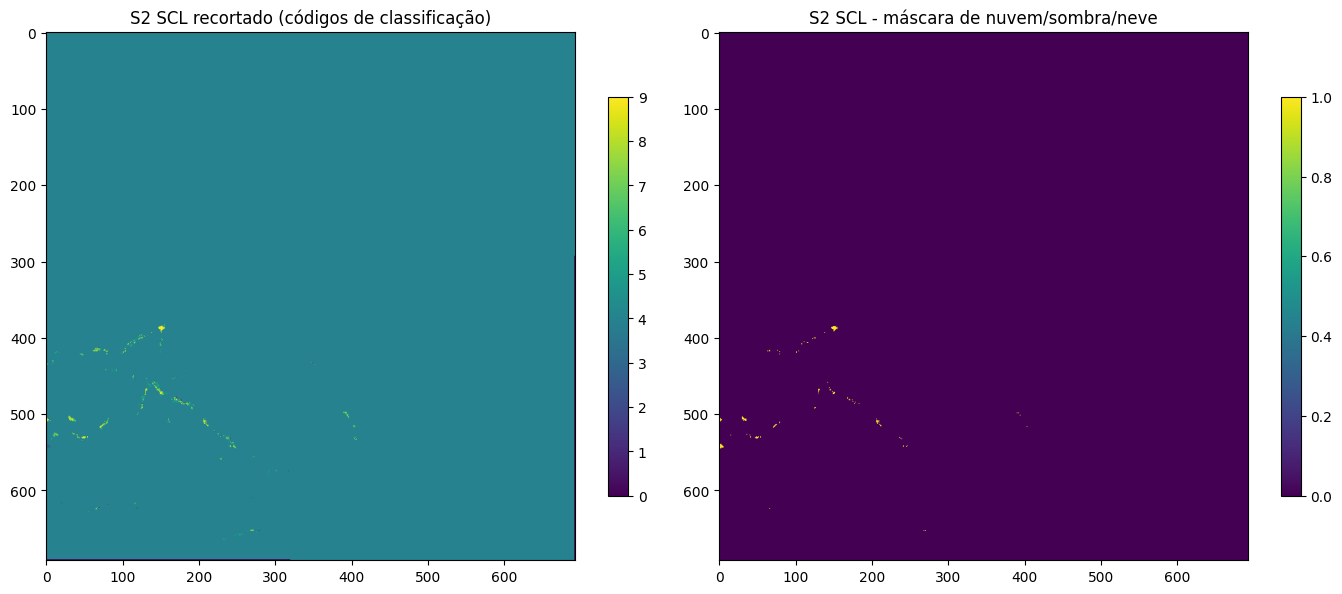

In [19]:
#!/usr/bin/env python
from __future__ import annotations

import json
import numpy as np
import matplotlib.pyplot as plt

import rioxarray
from pystac_client import Client
import planetary_computer

from sqlalchemy import create_engine, text

# ----------------------------------------------------------------------
# Configurações gerais
# ----------------------------------------------------------------------
PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

PG_USER = "postgres"
PG_PASS = "postgres"
PG_HOST = "localhost"
PG_PORT = "5432"
PG_DB   = "geologia"

PG_CONN_STR = (
    f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

FOLHA_CODIGO = "SB21_ZA_II2_NW"

# ASTER com cloud_cover = 0% e 100% de cobertura (do seu log)
ASTER_ID_CLOUD_FREE = "AST_L1T_00307292004141220_20150505110335"

# Sentinel-2 selecionada anteriormente
S2_ID_BEST = "S2A_MSIL2A_20170609T141051_R110_T21MWP_20210209T214220"

# ----------------------------------------------------------------------
# Acesso ao PostGIS: geometria da folha
# ----------------------------------------------------------------------
def get_folha_geom_geojson(
    codigo_folha: str,
    conn_str: str = PG_CONN_STR,
    schema: str = "carto",
    table: str = "folhas_cartograficas",
):
    """
    Retorna a geometria da folha em WGS84 (EPSG:4326) como dict GeoJSON.
    """
    engine = create_engine(conn_str)
    sql = text(
        f"""
        SELECT ST_AsGeoJSON(ST_Transform(geom, 4326)) AS geom_json
        FROM {schema}.{table}
        WHERE codigo = :codigo
        LIMIT 1;
        """
    )
    with engine.begin() as conn:
        row = conn.execute(sql, {"codigo": codigo_folha}).fetchone()

    if row is None or row.geom_json is None:
        raise RuntimeError(f"Não foi encontrada geometria para a folha '{codigo_folha}'")

    return json.loads(row.geom_json)


# ----------------------------------------------------------------------
# Planetary Computer / STAC
# ----------------------------------------------------------------------
def get_signed_item(collection_id: str, item_id: str):
    """
    Obtém um pystac.Item assinado (assets com SAS) da coleção/ID especificados.
    """
    api = Client.open(
        PC_STAC_URL,
        modifier=planetary_computer.sign_inplace,
    )
    search = api.search(
        collections=[collection_id],
        ids=[item_id],
        max_items=1,
    )
    item = next(search.items(), None)
    if item is None:
        raise RuntimeError(f"Item {item_id} não encontrado na coleção {collection_id}")
    return item


# ----------------------------------------------------------------------
# Recorte (clip) e métricas de nodata
# ----------------------------------------------------------------------
def clip_raster_to_folha(href: str, folha_geom_geojson: dict):
    """
    Abre o raster indicado por href, e recorta para a geometria da folha (EPSG:4326).
    Retorna um DataArray rioxarray recortado.
    """
    da = rioxarray.open_rasterio(href, masked=True)
    da_clip = da.rio.clip([folha_geom_geojson], crs="EPSG:4326", drop=True)
    return da_clip


def compute_nodata_fraction(da_clip):
    """
    Calcula fração de pixels nodata no recorte.
    Se tiver várias bandas, considera nodata quando TODAS as bandas são NaN.
    """
    arr = da_clip.values
    if arr.ndim == 3:
        nodata_mask = np.all(np.isnan(arr), axis=0)
    else:
        nodata_mask = np.isnan(arr)
    frac = nodata_mask.sum() / nodata_mask.size
    return frac, nodata_mask


# ----------------------------------------------------------------------
# ASTER: recorte + inspeção visual
# ----------------------------------------------------------------------
def inspect_aster_cloud_free():
    folha_geom = get_folha_geom_geojson(FOLHA_CODIGO)
    item = get_signed_item("aster-l1t", ASTER_ID_CLOUD_FREE)

    print(f"\n[ASTER] Item selecionado: {ASTER_ID_CLOUD_FREE}")
    print(f"  cloud_cover (metadado de cena): {item.properties.get('eo:cloud_cover')} %")

    assets = item.assets
    print("  Assets disponíveis:", list(assets.keys()))

    # Escolher VNIR (se existir)
    if "VNIR" in assets:
        asset_key = "VNIR"
    else:
        asset_key = list(assets.keys())[0]
        print(f"  Asset 'VNIR' não encontrado, usando '{asset_key}'.")

    href = assets[asset_key].href
    print(f"  Lendo asset '{asset_key}' e recortando para a folha...")

    da_clip = clip_raster_to_folha(href, folha_geom)
    frac_nodata, nodata_mask = compute_nodata_fraction(da_clip)

    print(f"  Fração de pixels nodata no recorte ASTER: {frac_nodata:.4f}")

    # Visualização: banda 1 e máscara
    if "band" in da_clip.dims:
        da_plot = da_clip.isel(band=0)
    else:
        da_plot = da_clip

    data = da_plot.values

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    im1 = ax1.imshow(data, origin="upper")
    ax1.set_title("ASTER VNIR recortado - intensidade (banda 1)")
    fig.colorbar(im1, ax=ax1, shrink=0.7)

    im2 = ax2.imshow(nodata_mask, origin="upper")
    ax2.set_title("ASTER VNIR recortado - máscara (True = nodata)")
    fig.colorbar(im2, ax=ax2, shrink=0.7)

    plt.tight_layout()
    plt.show()

    return da_clip, nodata_mask


# ----------------------------------------------------------------------
# Sentinel-2: recorte + máscara SCL (nuvem/nodata)
# ----------------------------------------------------------------------
def inspect_s2_with_scl():
    folha_geom = get_folha_geom_geojson(FOLHA_CODIGO)
    item = get_signed_item("sentinel-2-l2a", S2_ID_BEST)

    print(f"\n[S2] Item selecionado: {S2_ID_BEST}")
    print(f"  cloud_cover (metadado de cena): {item.properties.get('eo:cloud_cover')} %")
    print("  Assets disponíveis:", list(item.assets.keys()))

    # 1) Asset visual (RGB)
    if "visual" in item.assets:
        visual_key = "visual"
    else:
        visual_key = list(item.assets.keys())[0]
        print(f"  Asset 'visual' não encontrado, usando '{visual_key}'.")

    href_vis = item.assets[visual_key].href
    print(f"  Lendo asset '{visual_key}' e recortando para a folha...")

    da_vis_clip = clip_raster_to_folha(href_vis, folha_geom)
    frac_nodata_vis, nodata_mask_vis = compute_nodata_fraction(da_vis_clip)

    print(f"  Fração de pixels nodata no recorte S2 (visual): {frac_nodata_vis:.4f}")

    # Visualização RGB
    arr = da_vis_clip.values
    if arr.ndim == 3 and da_vis_clip.sizes.get("band", 1) >= 3:
        # (band, y, x) -> (y, x, band)
        arr = arr.astype("float32")
        valid = arr[~np.isnan(arr)]
        if valid.size > 0:
            vmin = np.nanpercentile(valid, 2)
            vmax = np.nanpercentile(valid, 98)
            scale = vmax - vmin if vmax > vmin else 1.0
            arr_scaled = (arr - vmin) / scale
            arr_scaled = np.clip(arr_scaled, 0, 1)
        else:
            arr_scaled = np.zeros_like(arr)

        rgb = np.transpose(arr_scaled[:3, :, :], (1, 2, 0))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        ax1.imshow(rgb)
        ax1.set_title("Sentinel-2 'visual' recortado (RGB)")

        ax2.imshow(nodata_mask_vis, origin="upper")
        ax2.set_title("Sentinel-2 'visual' - máscara (True = nodata)")
        plt.tight_layout()
        plt.show()
    else:
        data = da_vis_clip.values
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        im1 = ax1.imshow(data, origin="upper")
        ax1.set_title("Sentinel-2 recortado - intensidade")
        fig.colorbar(im1, ax=ax1, shrink=0.7)

        im2 = ax2.imshow(nodata_mask_vis, origin="upper")
        ax2.set_title("Sentinel-2 recortado - máscara (True = nodata)")
        fig.colorbar(im2, ax=ax2, shrink=0.7)
        plt.tight_layout()
        plt.show()

    # 2) Asset SCL (Scene Classification Layer) para nuvem/nodata
    if "SCL" not in item.assets:
        print("\n[S2] Asset 'SCL' não encontrado neste item. Não é possível calcular nuvem pixel a pixel.")
        return da_vis_clip, nodata_mask_vis, None, None

    href_scl = item.assets["SCL"].href
    print("  Lendo asset 'SCL' e recortando para a folha...")

    da_scl_clip = clip_raster_to_folha(href_scl, folha_geom)
    scl = da_scl_clip.values

    # SCL geralmente vem como (band=1, y, x) ou (y, x)
    if scl.ndim == 3:
        scl = scl[0, :, :]

    scl = scl.astype("int16")

    total = scl.size
    nodata_frac = np.sum(scl == 0) / total  # 0 = no data
    # Códigos SCL relevantes para nuvem:
    # 3 = cloud shadow, 8 = medium prob. cloud, 9 = high prob. cloud,
    # 10 = thin cirrus, 11 = snow/ice (geralmente indesejado também).
    cloud_mask = np.isin(scl, [3, 8, 9, 10, 11])
    cloud_frac = np.sum(cloud_mask) / total

    print(f"\n[S2] Fração de nodata no SCL (código 0): {nodata_frac:.4f}")
    print(f"[S2] Fração de 'nuvem/sombra/neve' (SCL in {{3,8,9,10,11}}): {cloud_frac:.4f}")

    # Visualização SCL e máscara de nuvem
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    im1 = ax1.imshow(scl, origin="upper")
    ax1.set_title("S2 SCL recortado (códigos de classificação)")
    fig.colorbar(im1, ax=ax1, shrink=0.7)

    im2 = ax2.imshow(cloud_mask, origin="upper")
    ax2.set_title("S2 SCL - máscara de nuvem/sombra/neve")
    fig.colorbar(im2, ax=ax2, shrink=0.7)
    plt.tight_layout()
    plt.show()

    return da_vis_clip, nodata_mask_vis, da_scl_clip, cloud_mask


# ----------------------------------------------------------------------
# Execução
# ----------------------------------------------------------------------
da_aster_clip, ast_nodata_mask = inspect_aster_cloud_free()
da_s2_vis_clip, s2_nodata_mask, da_s2_scl_clip, s2_cloud_mask = inspect_s2_with_scl()
